In [15]:
import os
import json
from pathlib import Path
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, classification_report

In [3]:
def prepare_validation_data(base_dir):
    
    normal_data = []      
    simple_crack = []     
    other_defects = []    

    json_paths = list(Path(base_dir).rglob("*.json"))
    
    for json_path in tqdm(json_paths):
        img_path_str = str(json_path).replace('02.라벨링데이터', '01.원천데이터')
        img_path_str = img_path_str.replace('02.라벨링데이터', '01.원천데이터')
        
        img_path_str = img_path_str.replace('VL_', 'VS_')
        
        img_path_str = img_path_str.replace('.json', '.jpg')        
        img_path = Path(img_path_str)
        
        if not img_path.exists():
            continue

        with open(json_path, 'r', encoding='utf-8') as f:
            try:
                data = json.load(f)
            except json.JSONDecodeError:
                continue
                
            img_info = data.get("image", {})
            is_defect = img_info.get("object_included", "N")
            
            if is_defect == "N":
                normal_data.append((str(img_path), 0))
            elif is_defect == "Y":
                annotations = img_info.get("annotations", [])
                labels = {ann.get("label", "").lower() for ann in annotations}
                
                if labels == {"crack"}:
                    simple_crack.append((str(img_path), 1))
                else:
                    other_defects.append((str(img_path), 1))

    final_data_list = normal_data + simple_crack + other_defects
    
    print(f" 전체 검증 데이터 수 : {len(final_data_list):,}")
    print(f" 정상 데이터 : {len(normal_data):,}")
    print(f" 단순 균열(1): {len(simple_crack):,}")
    print(f" 기타 결함(1): {len(other_defects):,}")
    
    return final_data_list

In [5]:
class CrackDataset(Dataset):
    def __init__(self, data_list, transform=None):
        self.data_list = data_list
        self.transform = transform

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        img_path, label = self.data_list[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)


100%|███████████████████████████████████████████████████████████████████████████| 52500/52500 [05:12<00:00, 168.02it/s]
C:\Users\SehoonChoi\AppData\Local\Temp\ipykernel_35348\1070081324.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue

 전체 검증 데이터 수 : 52,500
 전체 : 2,500
 단순 균열(1): 40,199
 기타 결함(1): 9,801


100%|████████████████████████████████████████████████████████████████████| 821/821 [30:28<00:00,  2.23s/it, acc=99.94%]


총 이미지 수: 52,500장
Loss  : 0.0020
Acc : 99.94%
Precision : 0.9999
Recall    : 0.9995
F1 Score  : 0.9997
              precision    recall  f1-score   support

       정상(0)     0.9897    0.9988    0.9942      2500
       결함(1)     0.9999    0.9995    0.9997     50000

    accuracy                         0.9994     52500
   macro avg     0.9948    0.9991    0.9970     52500
weighted avg     0.9995    0.9994    0.9994     52500



C:\Users\SehoonChoi\.conda\envs\cuda_default\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\SehoonChoi\.conda\envs\cuda_default\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\SehoonChoi\.conda\envs\cuda_default\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\SehoonChoi\.conda\envs\cuda_default\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 54632 (\N{HANGUL SYLLABLE HAM}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\SehoonChoi\.conda\envs\cuda_default\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SehoonCho

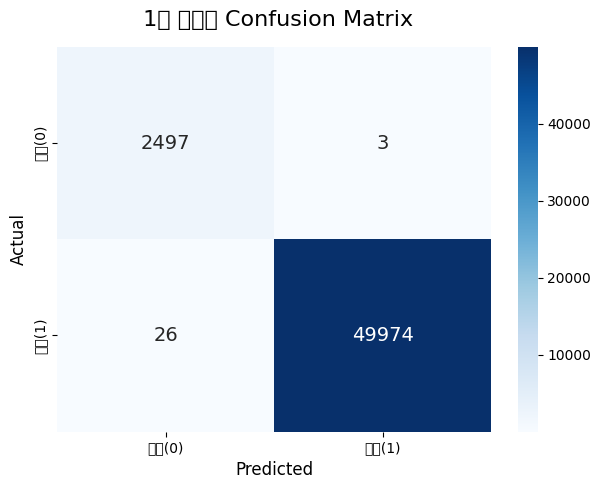

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

VAL_BASE_DIR = r"D:\Study\HumanStudy\Dataset\Validation"

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_data_list = prepare_validation_data(VAL_BASE_DIR)
val_dataset = CrackDataset(val_data_list, transform=val_transform)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

model_name = 'efficientnet_b0'
model = timm.create_model(model_name, pretrained=False, num_classes=2)
model.load_state_dict(torch.load('best_efficientnet_b0_crack_classifier.pth', map_location=device))
model = model.to(device)

model.eval()
criterion = nn.CrossEntropyLoss()

running_loss = 0.0
corrects = 0
total = 0

all_labels = []
all_preds = []

with torch.no_grad():
    pbar = tqdm(val_loader)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        corrects += torch.sum(preds == labels.data)
        total += labels.size(0)
        
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        
        current_acc = (corrects.item() / total) * 100
        pbar.set_postfix({'acc': f"{current_acc:.2f}%"})

val_loss = running_loss / total
val_acc = (corrects.item() / total) * 100
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print(f"총 이미지 수: {total:,}장")
print(f"Loss  : {val_loss:.4f}")
print(f"Acc : {val_acc:.2f}%")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print(classification_report(all_labels, all_preds, target_names=['정상(0)', '결함(1)'], digits=4))

#confusion matrix
cm = confusion_matrix(all_labels, all_preds)
    
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            annot_kws={"size": 14}, 
            xticklabels=['정상(0)', '결함(1)'], 
            yticklabels=['정상(0)', '결함(1)'])
    
plt.title(' 1차 분류기 Confusion Matrix', fontsize=16, pad=15)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()